In [31]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 

In [32]:
training_set = pd.read_csv('Salary_dataset.csv')
x_train = training_set["YearsExperience"].values
y_train = training_set["Salary"].values

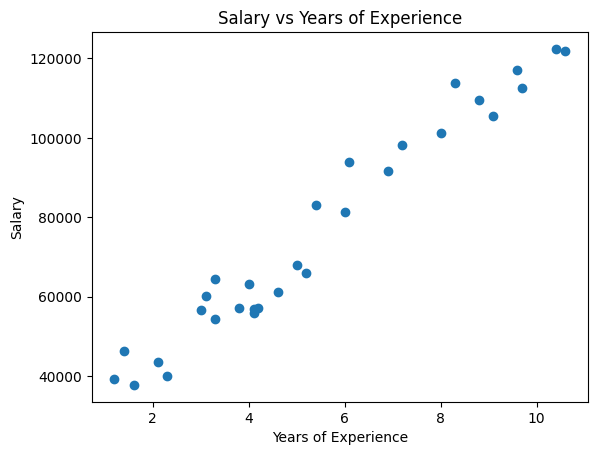

In [ ]:
plt.scatter(x_train, y_train)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Years of Experience")
plt.show()
/login

In [46]:
def cost_function(x, y, w, b):
   m = len(x)
   cost_sum = 0
   
   for i in range(m): #toplam ifadesi için 
      f_wb = w * x[i] + b #modelin athmini
      cost = (f_wb - y[i]) ** 2 #tahmin ile gerçek arasındaki fark
      cost_sum = cost_sum + cost
      
   total_cost = (1/(2*m)) * cost_sum
   return total_cost

In [35]:
def gradient_function(x, y, w,b):
   m = len(x)
   dc_dw = 0 #w için türev
   dc_db = 0 #b için türev
   
   for i in range(m):
      f_wb = w*x[i] + b
      
      dc_dw += (f_wb -y[i]) * x[i]
      dc_db += (f_wb - y[i])
      
   dc_dw = (1/m) * dc_dw
   dc_db = (1/m) * dc_db
   return dc_dw, dc_db

In [36]:
def gradient_descent(x, y, alpha, iterations):
   w = 0
   b = 0
   cost_history = []  # her iterasyondaki cost'u kaydet
   
   for i in range(iterations):
      dc_dw, dc_db = gradient_function(x, y, w, b)
      w = w - alpha * dc_dw
      b = b - alpha * dc_db
      
      current_cost = cost_function(x, y, w, b)
      cost_history.append(current_cost)
      
      if i % 100 == 0:  # her 100 adımda bir yazdır
         print(f"Iteration {i}: Cost {current_cost:.2f}, w: {w:.4f}, b: {b:.4f}")
      
   return w, b, cost_history

In [45]:
learning_rate = 0.01
iterations = 1000

final_w, final_b, cost_history = gradient_descent(x_train, y_train, learning_rate, iterations)
print(f"\nFinal → w: {final_w:.4f}, b: {final_b:.4f}")
print(f"Final cost: {cost_history[-1]:.2f}")

Iteration 0: Cost 1297963218.56, w: 4850.0441, b: 760.0400
Iteration 100: Cost 52175120.59, w: 12188.3276, b: 6190.3086
Iteration 200: Cost 39850504.71, w: 11679.1761, b: 9659.4206
Iteration 300: Cost 31682912.19, w: 11264.6925, b: 12483.5114
Iteration 400: Cost 26270202.51, w: 10927.2749, b: 14782.5115
Iteration 500: Cost 22683169.25, w: 10652.5942, b: 16654.0524
Iteration 600: Cost 20306022.06, w: 10428.9857, b: 18177.6127
Iteration 700: Cost 18730673.19, w: 10246.9533, b: 19417.8935
Iteration 800: Cost 17686680.61, w: 10098.7666, b: 20427.5655
Iteration 900: Cost 16994820.83, w: 9978.1327, b: 21249.5065

Final → w: 9880.8140, b: 21912.5892
Final cost: 16540035.38


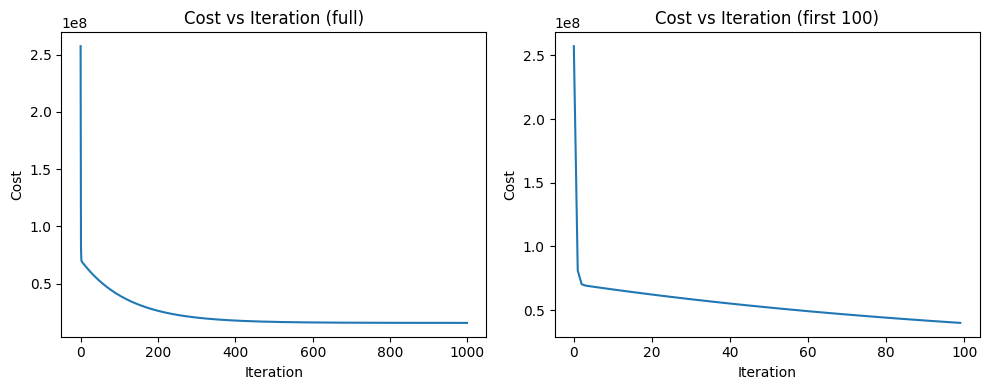

Yaklaşık RMSE (hata payı): $5,595
Yani modelimiz ortalama bu kadar yanılıyor.


In [38]:
# Cost vs Iteration grafiği — modelin öğrenme sürecini gösterir
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Iteration (full)")

# İlk 100 iterasyon — cost en hızlı burada düşer
plt.subplot(1, 2, 2)
plt.plot(cost_history[:100])
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Iteration (first 100)")

plt.tight_layout()
plt.show()

# Yorum: cost değeri J(w,b) = (1/2m) * Σ(tahmin - gerçek)²
# Salary büyük sayılar olduğu için cost değeri de büyük görünür.
# Önemli olan mutlak değer değil, her iterasyonda düşüyor olması.
import math
rmse = math.sqrt(2 * cost_history[-1])
print(f"Yaklaşık RMSE (hata payı): ${rmse:,.0f}")
print("Yani modelimiz ortalama bu kadar yanılıyor.")